In [1]:
TEST = False

INPUT_FN = "input_test.txt"
TEST_SOLUTION = 40

TEST_SOLUTION2 = 25272

if not TEST:
    INPUT_FN = "input.txt"

def printd(s):
    if TEST:
        print (s)

In [2]:
# with open(INPUT_FN) as f:
#     s = f.read()

# patterns_block, designs_block = s.split('\n\n')

# Read and split lines
with open(INPUT_FN) as f:
    lines = [l.rstrip() for l in f]

if lines[-1]=='':
    lines=lines[:-1]

In [3]:
NCONN = 1000
if TEST:
    NCONN=10

In [4]:
lines

['28839,16674,88793',
 '29162,10607,47022',
 '58380,29471,46772',
 '53949,83540,13930',
 '11183,17766,11176',
 '61373,81011,98751',
 '36175,72813,59266',
 '30426,67953,50954',
 '41695,95037,84822',
 '57428,4118,78998',
 '1258,10335,99516',
 '86005,23974,12506',
 '80772,13542,99369',
 '69551,59998,38336',
 '920,52747,91976',
 '74046,84159,36322',
 '23002,52101,58177',
 '31406,81158,78225',
 '15310,4035,36063',
 '52990,99872,95028',
 '19706,36855,27077',
 '12575,52169,37052',
 '25335,89999,41693',
 '95439,29383,51917',
 '45307,39806,4155',
 '10809,59705,4175',
 '6328,86726,20388',
 '31359,63508,57453',
 '86483,99542,62061',
 '71769,78077,97079',
 '20783,99905,68899',
 '40335,96531,22526',
 '59642,49413,22350',
 '31307,13092,78503',
 '41716,3182,2052',
 '30579,42802,28334',
 '42608,60962,52744',
 '95019,79410,8181',
 '58043,27148,85002',
 '52305,27711,12276',
 '93227,36179,30343',
 '66394,26566,40388',
 '24988,39612,1029',
 '52179,33777,44904',
 '9765,36804,57491',
 '75650,40572,8689',
 '

- Get coordinates of each box.
- For all pairs, get the shortest lengths ( we can perhaps calculate them while parsing the file)
- add the shortest lengths to a heapq. We may need to define a less_than operation for each connection. This also means that connections must be a class
- Get the 10 shortest lengths to a list, maybe create a connected graph
- Determine the largest circuits (networkx should be able to provide that answer)
- Get solution by multiplying the largest circuits by size


In [5]:
class cBoxEdge():
    length_sq=0
    def __init__(self, box0, box1):
        self.boxes = (box0,box1)
        self.length_sq = (box0[0]-box1[0])**2 + (box0[1]-box1[1])**2 + (box0[2]-box1[2])**2
    
    def __lt__(self, other):
        if not isinstance(other, cBoxEdge):
            return NotImplemented
        return self.length_sq < other.length_sq

Parse lines

In [6]:
import heapq

In [7]:
boxes_coords = []
cedges = []
heapq.heapify(cedges)

for line0 in lines:
    this_box = tuple(map(int,line0.split(',')))
    printd(this_box)
    #Get all the edges and put them in cedges
    for bc in boxes_coords:
        printd(f"{bc=}, {this_box=}")
        cedge0 = cBoxEdge(bc, this_box)
        printd(f"{cedge0.boxes=}")
        heapq.heappush(cedges, cedge0) #add edge element
    
    boxes_coords.append(this_box)

In [8]:
boxes_coords

[(28839, 16674, 88793),
 (29162, 10607, 47022),
 (58380, 29471, 46772),
 (53949, 83540, 13930),
 (11183, 17766, 11176),
 (61373, 81011, 98751),
 (36175, 72813, 59266),
 (30426, 67953, 50954),
 (41695, 95037, 84822),
 (57428, 4118, 78998),
 (1258, 10335, 99516),
 (86005, 23974, 12506),
 (80772, 13542, 99369),
 (69551, 59998, 38336),
 (920, 52747, 91976),
 (74046, 84159, 36322),
 (23002, 52101, 58177),
 (31406, 81158, 78225),
 (15310, 4035, 36063),
 (52990, 99872, 95028),
 (19706, 36855, 27077),
 (12575, 52169, 37052),
 (25335, 89999, 41693),
 (95439, 29383, 51917),
 (45307, 39806, 4155),
 (10809, 59705, 4175),
 (6328, 86726, 20388),
 (31359, 63508, 57453),
 (86483, 99542, 62061),
 (71769, 78077, 97079),
 (20783, 99905, 68899),
 (40335, 96531, 22526),
 (59642, 49413, 22350),
 (31307, 13092, 78503),
 (41716, 3182, 2052),
 (30579, 42802, 28334),
 (42608, 60962, 52744),
 (95019, 79410, 8181),
 (58043, 27148, 85002),
 (52305, 27711, 12276),
 (93227, 36179, 30343),
 (66394, 26566, 40388),
 (2

In [9]:
len(boxes_coords)

1000

In [10]:
len(cedges)

499500

View distances^2

In [11]:
for i,c0 in enumerate(cedges):
    printd(f"edge {i} : {c0.boxes=} , {c0.length_sq}")

# Top of the list is the shortest edge

Connnect the NCONN shortest ones

In [12]:
NCONN

1000

In [13]:
cedges_best = []

for i in range(NCONN):
#for i in range(400): # debug
    c0 = cedges[0]
    heapq.heappop(cedges)

    cedges_best.append(c0.boxes)

In [14]:
cedges_best

[((22662, 6955, 7124), (22772, 6437, 7418)),
 ((920, 52747, 91976), (770, 52177, 91358)),
 ((42553, 71880, 29425), (43033, 72228, 28791)),
 ((15380, 19660, 32704), (14656, 18849, 33244)),
 ((37906, 65907, 6058), (37722, 67135, 5895)),
 ((81678, 82926, 23052), (82215, 83791, 22210)),
 ((2063, 92337, 39347), (3334, 92501, 40239)),
 ((63502, 18502, 70887), (64925, 17822, 70885)),
 ((45307, 39806, 4155), (46489, 40376, 2913)),
 ((92384, 71229, 4904), (93976, 70443, 5258)),
 ((66381, 11590, 38596), (64584, 11393, 39148)),
 ((10466, 12639, 4121), (9446, 12943, 2526)),
 ((96149, 7722, 78223), (94776, 6539, 78851)),
 ((97992, 22128, 48571), (99950, 22091, 48206)),
 ((45135, 53096, 88481), (46881, 53171, 87491)),
 ((56071, 93540, 16298), (57450, 94992, 16778)),
 ((11183, 17766, 11176), (11838, 19540, 10195)),
 ((94302, 8407, 51987), (93570, 8142, 49999)),
 ((62600, 98360, 91994), (62303, 97857, 89910)),
 ((24988, 39612, 1029), (23094, 38540, 1003)),
 ((6885, 5471, 33589), (5015, 4559, 32673)),


In [15]:
len(cedges_best)

1000

Create a networkx graph

In [16]:
import networkx as nx

In [17]:
G = nx.Graph()
for c0 in cedges_best:
    printd(c0)
    G.add_edge(*c0)

In [18]:
G.nodes

NodeView(((22662, 6955, 7124), (22772, 6437, 7418), (920, 52747, 91976), (770, 52177, 91358), (42553, 71880, 29425), (43033, 72228, 28791), (15380, 19660, 32704), (14656, 18849, 33244), (37906, 65907, 6058), (37722, 67135, 5895), (81678, 82926, 23052), (82215, 83791, 22210), (2063, 92337, 39347), (3334, 92501, 40239), (63502, 18502, 70887), (64925, 17822, 70885), (45307, 39806, 4155), (46489, 40376, 2913), (92384, 71229, 4904), (93976, 70443, 5258), (66381, 11590, 38596), (64584, 11393, 39148), (10466, 12639, 4121), (9446, 12943, 2526), (96149, 7722, 78223), (94776, 6539, 78851), (97992, 22128, 48571), (99950, 22091, 48206), (45135, 53096, 88481), (46881, 53171, 87491), (56071, 93540, 16298), (57450, 94992, 16778), (11183, 17766, 11176), (11838, 19540, 10195), (94302, 8407, 51987), (93570, 8142, 49999), (62600, 98360, 91994), (62303, 97857, 89910), (24988, 39612, 1029), (23094, 38540, 1003), (6885, 5471, 33589), (5015, 4559, 32673), (21540, 98996, 77215), (22563, 98366, 75251), (92324,

In [19]:
len(G.nodes)

845

In [20]:
len(G.edges)

1000

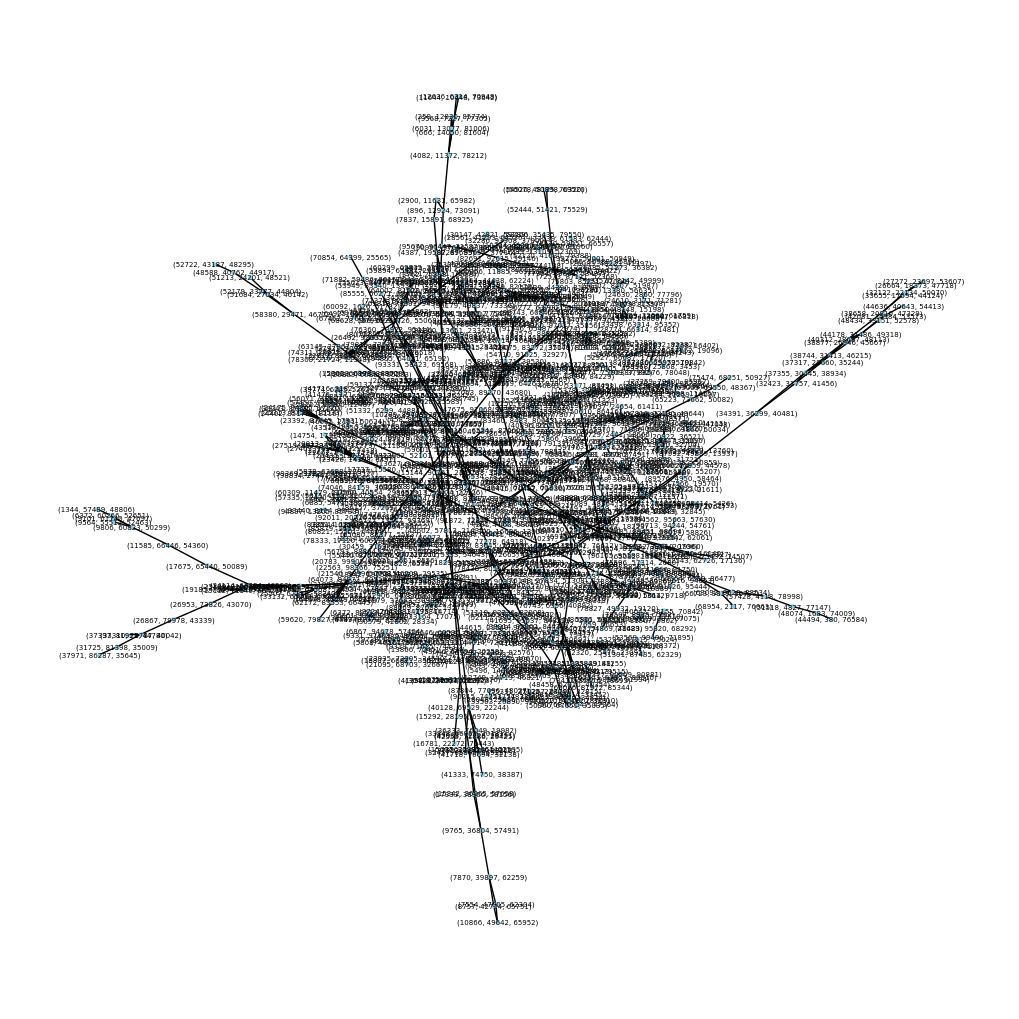

In [21]:
import matplotlib.pyplot as plt
poss = nx.spring_layout(G)
plt.figure(figsize=(10, 10))
nx.draw(G, poss, with_labels=True, node_color='skyblue', node_size=5, font_size=5)
#nx.draw(G, poss, node_size=10)
plt.show()

In [22]:
connected = list(nx.connected_components(G))

In [23]:
connected

[{(1300, 16686, 13908),
  (2046, 6709, 15596),
  (2619, 5614, 9718),
  (2642, 6715, 21579),
  (2690, 4326, 20803),
  (4319, 12917, 20229),
  (4756, 18514, 9565),
  (11183, 17766, 11176),
  (11838, 19540, 10195),
  (14754, 173, 7567),
  (15446, 22659, 7551),
  (16779, 5900, 11279),
  (17737, 15580, 7171),
  (19282, 12366, 5797),
  (20013, 2042, 3974),
  (20435, 12775, 10812),
  (22662, 6955, 7124),
  (22772, 6437, 7418),
  (23420, 14193, 6451),
  (27467, 7416, 2472),
  (27519, 427, 379)},
 {(770, 52177, 91358), (920, 52747, 91976), (2864, 57087, 86477)},
 {(32457, 65860, 26922),
  (33848, 66952, 20181),
  (35622, 82661, 22595),
  (36333, 76049, 19982),
  (37903, 76448, 28218),
  (40128, 69529, 22244),
  (41333, 74750, 38387),
  (41718, 76694, 32138),
  (42553, 71880, 29425),
  (43033, 72228, 28791),
  (43046, 64794, 20259),
  (44672, 59870, 26203),
  (48602, 57813, 21435),
  (49848, 49225, 20761),
  (51913, 55474, 22126),
  (54567, 54158, 16096),
  (55411, 58938, 21882),
  (56025, 47852

In [24]:
len(connected)

140

In [25]:
conn_sizes = [len(c0) for c0 in connected]
conn_sizes

[21,
 3,
 27,
 9,
 5,
 14,
 7,
 34,
 2,
 9,
 25,
 3,
 8,
 9,
 21,
 3,
 3,
 3,
 8,
 3,
 3,
 3,
 59,
 6,
 4,
 15,
 3,
 31,
 12,
 3,
 7,
 19,
 4,
 3,
 4,
 10,
 3,
 5,
 11,
 4,
 6,
 5,
 4,
 2,
 24,
 10,
 4,
 4,
 22,
 5,
 2,
 29,
 3,
 2,
 8,
 5,
 11,
 11,
 7,
 2,
 12,
 7,
 3,
 6,
 2,
 2,
 3,
 2,
 3,
 9,
 2,
 2,
 2,
 3,
 2,
 3,
 5,
 7,
 2,
 6,
 2,
 3,
 5,
 3,
 3,
 2,
 4,
 9,
 6,
 2,
 2,
 5,
 2,
 4,
 2,
 4,
 3,
 3,
 2,
 2,
 3,
 5,
 2,
 4,
 2,
 4,
 2,
 4,
 2,
 4,
 2,
 2,
 3,
 2,
 3,
 2,
 3,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 3,
 2,
 3,
 2,
 2,
 2,
 2,
 4,
 2,
 3,
 4,
 2,
 2,
 2,
 2,
 2]

In [26]:
conn_sizes.sort(reverse=True)

In [27]:
conn_sizes

[59,
 34,
 31,
 29,
 27,
 25,
 24,
 22,
 21,
 21,
 19,
 15,
 14,
 12,
 12,
 11,
 11,
 11,
 10,
 10,
 9,
 9,
 9,
 9,
 9,
 8,
 8,
 8,
 7,
 7,
 7,
 7,
 7,
 6,
 6,
 6,
 6,
 6,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 5,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 4,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 3,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2,
 2]

In [28]:
largest_3_mult = 1
for i in range(3):
    if i<len(conn_sizes):
        largest_3_mult *= conn_sizes[i]

In [29]:
if TEST:
    assert largest_3_mult == TEST_SOLUTION
largest_3_mult

62186

# Part 2
Connect until all connected

Continue from last but need to ensure all nodes are added

In [30]:
G2 = G.copy()

In [31]:
# add all nodes
G2.add_nodes_from(boxes_coords)

In [32]:
while True:
    c0 = cedges[0]
    heapq.heappop(cedges)

    
    G2.add_edge(*c0.boxes)

    # Check circuits

    ncomp = nx.number_connected_components(G2)
    printd(f"New edge: {c0.boxes}. Resulted in {ncomp=}")
    if ncomp==1:
        print(f"All circuit completed with edge {c0.boxes}")
        break

All circuit completed with edge ((86005, 23974, 12506), (97906, 28543, 4213))


In [33]:
c0.boxes

((86005, 23974, 12506), (97906, 28543, 4213))

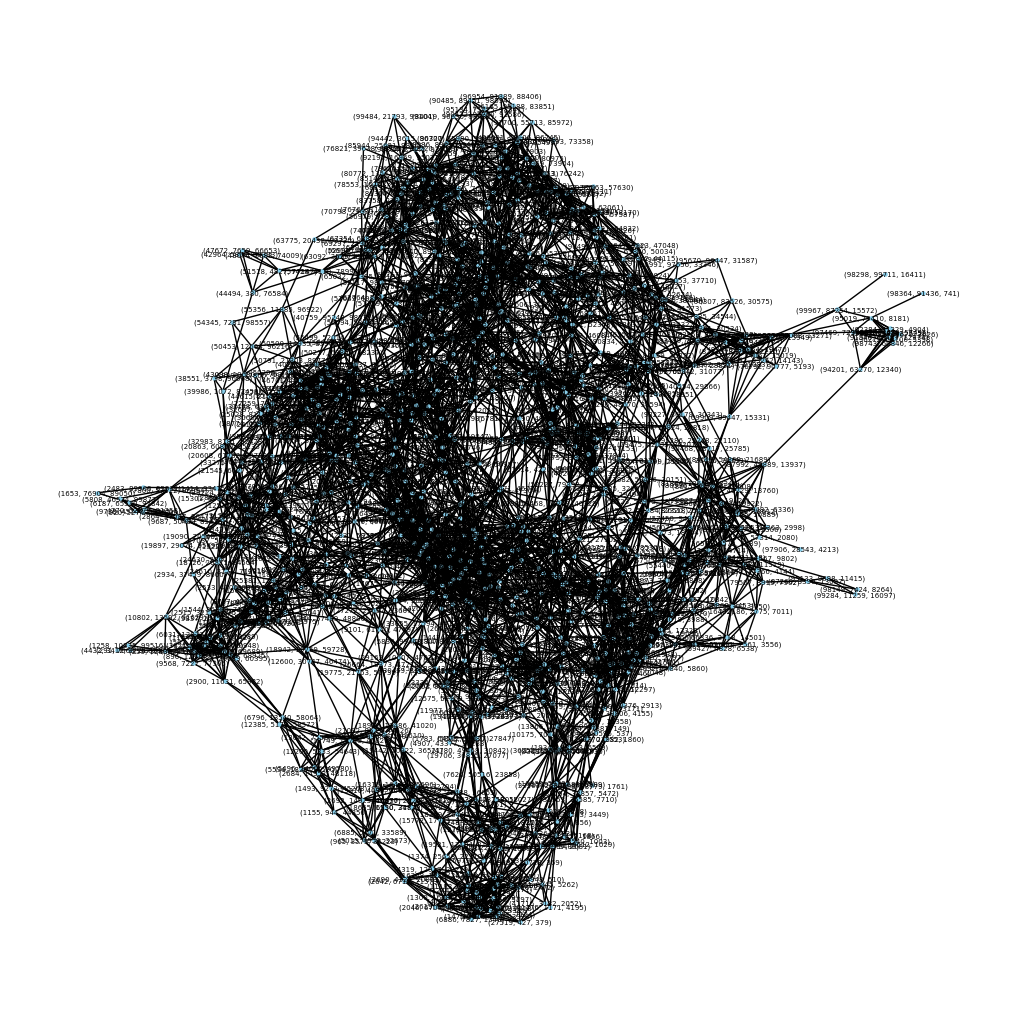

In [34]:
poss2 = nx.spring_layout(G2)
plt.figure(figsize=(10, 10))
nx.draw(G2, poss2, with_labels=True, node_color='skyblue', node_size=5, font_size=5)
plt.show()

In [35]:
x_mult = c0.boxes[0][0] * c0.boxes[1][0]

In [36]:
if TEST:
    assert TEST_SOLUTION2 == x_mult
x_mult

8420405530